# Limpieza de datos — kajve
### Paso 2.5 del pipeline: limpieza previa a ingeniería de características / entrenamiento

Este notebook toma los hallazgos del EDA (`02_eda_datos_reales.ipynb`) y los convierte en un
**dataset limpio y documentado**, listo para el siguiente paso del pipeline (ingeniería de
características / entrenamiento). Cada regla de limpieza está explícitamente justificada y se
muestra el efecto antes/después.

**Entrada:** `data/raw/lecturas_reales_entrenamiento.csv` (mismo dataset del EDA).
**Salida:** `data/processed/lecturas_reales_limpias.csv`.

**Hallazgos del EDA que esta limpieza atiende:**
1. Duplicados exactos y por `(id_lote, timestamp)`.
2. Glitch de sensor en `temperatura_ambiental` (181.55°C — físicamente imposible).
3. Parpadeo del sensor de lluvia (FC-37): `lluvia_detectada` alterna `True`/`False` en segundos.
4. Lotes de prueba (`DHT22-test`, sensor sin vincular) con muy pocas lecturas, que no representan
   el proceso real de secado y contaminarían cualquier estadística o modelo si se mezclan sin filtrar.
5. Valores nulos concentrados en ciertas columnas/periodos (no aleatorios — corresponden a una etapa
   del firmware antes de que se agregaran ciertos sensores/columnas).

**Nota importante de alcance:** dos de estos hallazgos (el glitch de ambiental y el parpadeo de
lluvia) **no están resueltos todavía en el motor de reglas de producción**
(`app/services/rules.py`) — ahí `clasificar_valor_imposible()` solo valida `temperatura_grano`, y
`clasificar_lluvia()` es un umbral instantáneo sin ventana de "sostenida". Este notebook limpia el
dataset para EDA/entrenamiento; la corrección en `rules.py` (que afecta a las alertas en vivo) queda
como recomendación separada, al final.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100


## 1. Carga de datos crudos

In [2]:
RUTA_CRUDA = "../data/raw/lecturas_reales_entrenamiento.csv"
df = pd.read_csv(RUTA_CRUDA, parse_dates=["timestamp"])
df = df.sort_values(["id_lote", "timestamp"]).reset_index(drop=True)
n_inicial = len(df)
print(f"Filas cargadas: {n_inicial:,}  |  Lotes: {df['id_lote'].nunique()}")
df.head()


Filas cargadas: 7,692  |  Lotes: 4


,id_lote,nombre_lote,estado_lote,tipo_proceso,timestamp,horas_transcurridas,horas_restantes,temperatura_grano,temperatura_ambiental,humedad_grano_raw,presion_hpa,altitud_m,lluvia_analog,lluvia_detectada,lluvia,luz,delta_temp,_es_anomalia,_severidad,_tipo_anomalia
0,4,nuevo,en_proceso,natural,2026-07-07 01:22:58.424086,82.129227,NaN,NaN,27.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,False,normal,normal
1,4,nuevo,en_proceso,natural,2026-07-07 02:22:58.424086,83.129227,NaN,NaN,29.5,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,False,normal,normal
2,4,nuevo,en_proceso,natural,2026-07-07 03:22:58.424086,84.129227,NaN,NaN,31.2,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,False,normal,normal
3,4,nuevo,en_proceso,natural,2026-07-07 04:22:58.424086,85.129227,NaN,NaN,32.8,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,False,normal,normal
4,8,perez,en_proceso,natural,2026-07-06 20:15:01.203790,36.755306,NaN,NaN,24.5,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,False,normal,normal


### Bitácora de limpieza

Cada paso siguiente registra cuántas filas afecta, para poder auditar al final exactamente cuánto
del dataset original se conservó y por qué.

In [3]:
bitacora = []

def registrar(paso, antes, despues, nota=""):
    bitacora.append({"paso": paso, "filas_antes": antes, "filas_despues": despues,
                      "filas_removidas": antes - despues, "nota": nota})

df_limpio = df.copy()


## 2. Duplicados

In [4]:
dup_exactos = df_limpio.duplicated().sum()
dup_clave = df_limpio.duplicated(subset=["id_lote", "timestamp"]).sum()
print(f"Duplicados exactos (todas las columnas iguales): {dup_exactos}")
print(f"Duplicados por (id_lote, timestamp): {dup_clave}")

antes = len(df_limpio)
df_limpio = df_limpio.drop_duplicates(subset=["id_lote", "timestamp"], keep="first")
despues = len(df_limpio)
registrar("Eliminar duplicados (id_lote, timestamp)", antes, despues)
print(f"Filas removidas: {antes - despues}")


Duplicados exactos (todas las columnas iguales): 8
Duplicados por (id_lote, timestamp): 10
Filas removidas: 10


**Justificación:** una misma combinación de sensor/timestamp no debería repetirse; son reintentos
de escritura o duplicación en la extracción, no lecturas distintas. Se conserva la primera ocurrencia.

## 3. Filtrado de lotes de prueba (volumen insuficiente)

In [5]:
resumen_lotes = (
    df_limpio.groupby(["id_lote", "nombre_lote", "estado_lote", "tipo_proceso"])
             .size().rename("n_lecturas").reset_index()
             .sort_values("n_lecturas", ascending=False)
)
resumen_lotes


,id_lote,nombre_lote,estado_lote,tipo_proceso,n_lecturas
3,12,Lote kajve-CA689C,en_proceso,lavado,7470
2,10,Sin vincular - kajve-CA689C,cancelado,lavado,204
1,8,perez,en_proceso,natural,4
0,4,nuevo,en_proceso,natural,4


In [6]:
MIN_LECTURAS_LOTE = 50  # por debajo de esto, es un sensor de prueba/humo, no un ciclo real de secado

lotes_validos = resumen_lotes.loc[resumen_lotes["n_lecturas"] >= MIN_LECTURAS_LOTE, "id_lote"].tolist()
lotes_descartados = resumen_lotes.loc[resumen_lotes["n_lecturas"] < MIN_LECTURAS_LOTE]
print(f"Lotes que se conservan (>= {MIN_LECTURAS_LOTE} lecturas): {lotes_validos}")
print("Lotes descartados por bajo volumen (sensores de prueba):")
print(lotes_descartados[["id_lote", "nombre_lote", "n_lecturas"]])

antes = len(df_limpio)
df_limpio = df_limpio[df_limpio["id_lote"].isin(lotes_validos)].copy()
despues = len(df_limpio)
registrar(f"Filtrar lotes con < {MIN_LECTURAS_LOTE} lecturas (prueba/humo)", antes, despues,
          nota=f"lotes descartados: {lotes_descartados['id_lote'].tolist()}")
print(f"Filas removidas: {antes - despues}")


Lotes que se conservan (>= 50 lecturas): [12, 10]
Lotes descartados por bajo volumen (sensores de prueba):
   id_lote nombre_lote  n_lecturas
1        8       perez           4
0        4       nuevo           4
Filas removidas: 8


**Justificación:** los lotes 4 y 8 (`DHT22-test`, 4 lecturas cada uno) son pruebas de integración,
no ciclos reales de secado — mezclarlos distorsionaría cualquier estadística agregada. El umbral
(`MIN_LECTURAS_LOTE = 50`) es deliberadamente genérico para que el mismo notebook siga funcionando
cuando existan más lotes reales, en vez de hardcodear "solo id_lote == 12".

El lote 10 (sensor kajve-CA689C sin vincular todavía a un usuario, 204 lecturas, `cancelado`) sí
supera el umbral de volumen, pero se trata del **mismo sensor físico** que después se vinculó como
lote 12 — es decir, es preproducción del mismo piloto, no un lote de proceso independiente. Se
conserva en el dataset (cumple el volumen mínimo) pero se documenta aquí para que quede claro que no
es un segundo sensor real independiente.

## 4. Glitch de sensor: `temperatura_ambiental` fuera de rango físico

In [7]:
RANGO_AMBIENTAL_MIN, RANGO_AMBIENTAL_MAX = -10.0, 60.0  # rango exterior razonable (heurística EDA)

antes_desc = df_limpio["temperatura_ambiental"].describe()
mask_glitch = (df_limpio["temperatura_ambiental"] < RANGO_AMBIENTAL_MIN) | (df_limpio["temperatura_ambiental"] > RANGO_AMBIENTAL_MAX)
print(f"Lecturas con temperatura_ambiental fuera de [{RANGO_AMBIENTAL_MIN}, {RANGO_AMBIENTAL_MAX}]°C: {mask_glitch.sum()}")
df_limpio.loc[mask_glitch, ["id_lote", "timestamp", "temperatura_grano", "temperatura_ambiental"]]


Lecturas con temperatura_ambiental fuera de [-10.0, 60.0]°C: 12


,id_lote,timestamp,temperatura_grano,temperatura_ambiental
4427,12,2026-07-20 07:36:24.893732,NaN,181.55
4450,12,2026-07-20 07:36:40.615482,NaN,181.55
4459,12,2026-07-20 07:36:45.622123,NaN,181.55
4647,12,2026-07-20 07:38:21.059005,NaN,181.55
4649,12,2026-07-20 07:38:21.611696,NaN,181.55
6737,12,2026-07-20 09:33:22.957149,NaN,181.55
6738,12,2026-07-20 09:33:23.519466,NaN,181.55
6739,12,2026-07-20 09:33:26.227004,NaN,181.55
6740,12,2026-07-20 09:33:26.785099,NaN,181.55
6741,12,2026-07-20 09:34:24.735461,NaN,181.55


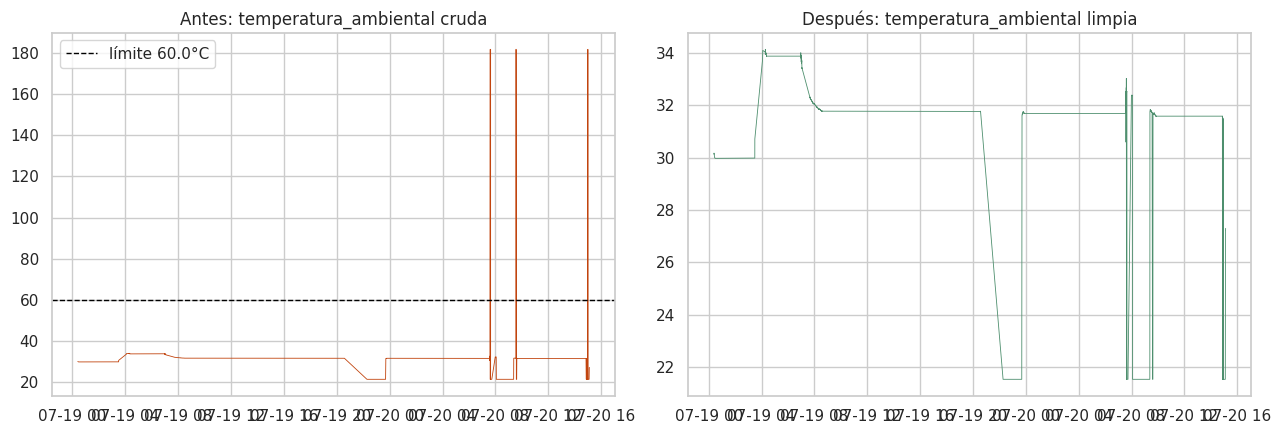

Filas removidas: 12


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(df_limpio["timestamp"], df_limpio["temperatura_ambiental"], linewidth=0.6, color="#c1440e")
axes[0].axhline(RANGO_AMBIENTAL_MAX, color="black", linestyle="--", linewidth=1, label=f"límite {RANGO_AMBIENTAL_MAX}°C")
axes[0].set_title("Antes: temperatura_ambiental cruda")
axes[0].legend()

antes = len(df_limpio)
df_limpio = df_limpio[~mask_glitch].copy()
despues = len(df_limpio)
registrar("Eliminar glitch de temperatura_ambiental fuera de rango físico", antes, despues,
          nota=f"rango válido [{RANGO_AMBIENTAL_MIN}, {RANGO_AMBIENTAL_MAX}]°C")

axes[1].plot(df_limpio["timestamp"], df_limpio["temperatura_ambiental"], linewidth=0.6, color="#4e8f6e")
axes[1].set_title("Después: temperatura_ambiental limpia")
fig.tight_layout()
plt.show()
print(f"Filas removidas: {antes - despues}")


**Justificación:** 181.55°C es físicamente imposible para una lectura de temperatura ambiente en
exterior en Chiapas — es ruido/glitch del sensor BMP280 (falla de lectura puntual), no una condición
climática real. Se elimina la fila completa (no se imputa un valor), porque no hay forma confiable de
saber qué habría leído el sensor correctamente en ese instante.

**Nota para el equipo:** esta misma validación no existe hoy en `app/services/rules.py` — vale la
pena portarla ahí (ver recomendaciones al final) para que el motor de reglas en vivo tampoco confunda
este tipo de glitch con una condición real.

## 5. Sensor de lluvia: de "parpadeo" a "lluvia sostenida"

In [9]:
print("Antes de limpiar — value_counts de lluvia_detectada:")
print(df_limpio["lluvia_detectada"].value_counts(dropna=False))


Antes de limpiar — value_counts de lluvia_detectada:
lluvia_detectada
False    5437
NaN      2156
True       69
Name: count, dtype: int64


In [10]:
def calcular_lluvia_sostenida(grupo, ventana_minutos=3, minimo_lecturas=2):
    """Réplica de la lógica de 'lluvia sostenida' construida y validada en el motor de reglas
    standalone (kajve_ml/reglas.py) durante la simulación offline: una lectura solo cuenta como
    lluvia sostenida si, dentro de una ventana de `ventana_minutos`, hay al menos
    `minimo_lecturas` lecturas positivas de lluvia_detectada. Esto filtra el rebote/parpadeo del
    FC-37 sin perder lluvia real (que sí se sostiene en el tiempo)."""
    g = grupo.sort_values("timestamp").set_index("timestamp")
    positivos = g["lluvia_detectada"].fillna(False).astype(int)
    conteo_ventana = positivos.rolling(f"{ventana_minutos}min").sum()
    sostenida = g["lluvia_detectada"].fillna(False) & (conteo_ventana >= minimo_lecturas)
    return pd.Series(sostenida.values, index=grupo.index)

partes = []
for _, grupo in df_limpio.groupby("id_lote"):
    partes.append(calcular_lluvia_sostenida(grupo))
df_limpio["lluvia_sostenida"] = pd.concat(partes).sort_index()

print("Después — value_counts de lluvia_sostenida (nueva columna):")
print(df_limpio["lluvia_sostenida"].value_counts(dropna=False))


Después — value_counts de lluvia_sostenida (nueva columna):
lluvia_sostenida
False    7598
True       64
Name: count, dtype: int64


/sessions/elegant-optimistic-ptolemy/tmp/ipykernel_8/322093377.py:8: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  positivos = g["lluvia_detectada"].fillna(False).astype(int)
/sessions/elegant-optimistic-ptolemy/tmp/ipykernel_8/322093377.py:10: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sostenida = g["lluvia_detectada"].fillna(False) & (conteo_ventana >= minimo_lecturas)
/sessions/elegant-optimistic-ptolemy/tmp/ipykernel_8/322093377.py:8: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a futur

/sessions/elegant-optimistic-ptolemy/tmp/ipykernel_8/3287662630.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  axes[0].step(ventana["timestamp"], ventana["lluvia_detectada"].fillna(False).astype(float), where="post", color="#c1440e")


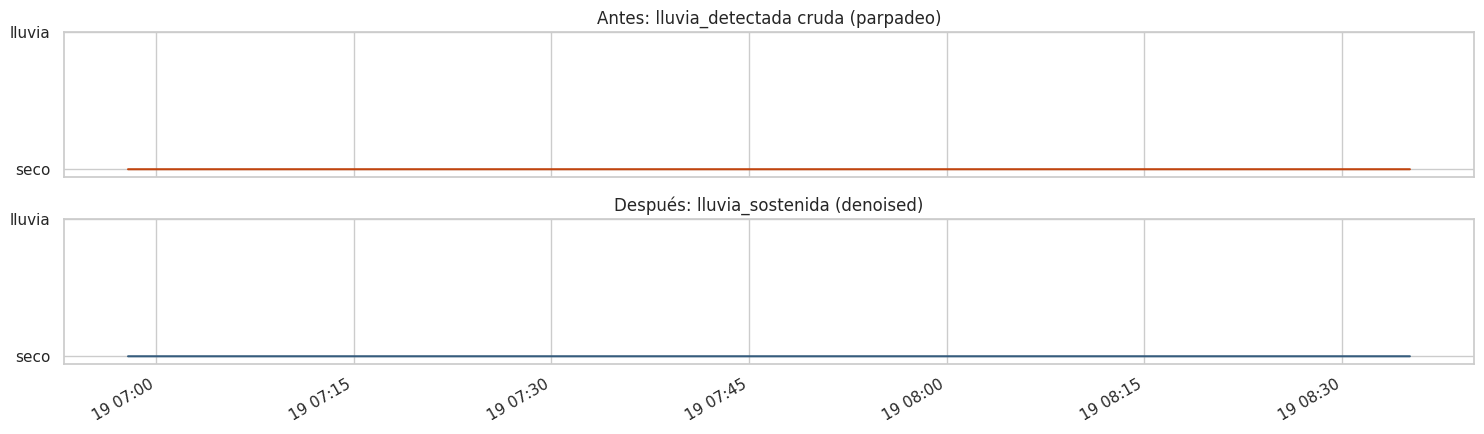

In [11]:
lote_real = df_limpio["id_lote"].value_counts().idxmax()
d = df_limpio[df_limpio["id_lote"] == lote_real]
ventana = d[d["timestamp"] < d["timestamp"].min() + pd.Timedelta(hours=6)]

fig, axes = plt.subplots(2, 1, figsize=(15, 4.5), sharex=True)
axes[0].step(ventana["timestamp"], ventana["lluvia_detectada"].fillna(False).astype(float), where="post", color="#c1440e")
axes[0].set_yticks([0, 1]); axes[0].set_yticklabels(["seco", "lluvia"])
axes[0].set_title("Antes: lluvia_detectada cruda (parpadeo)")

axes[1].step(ventana["timestamp"], ventana["lluvia_sostenida"].astype(float), where="post", color="#355c7d")
axes[1].set_yticks([0, 1]); axes[1].set_yticklabels(["seco", "lluvia"])
axes[1].set_title("Después: lluvia_sostenida (denoised)")

fig.autofmt_xdate()
fig.tight_layout()
plt.show()


**Justificación:** no se elimina ninguna fila aquí — el ruido del sensor de lluvia no es un valor
imposible, es una señal binaria demasiado sensible. En vez de descartar datos, se agrega una columna
derivada (`lluvia_sostenida`) que filtra el rebote, replicando la misma ventana (3 min, mínimo 2
lecturas) ya validada en la simulación offline del motor de reglas standalone. `lluvia_detectada`
cruda se conserva en el dataset por transparencia, pero **`lluvia_sostenida` es la que debería usarse**
para entrenamiento y para cualquier regla de negocio.

**Nota para el equipo:** `app/services/rules.py::clasificar_lluvia()` sigue usando la señal cruda
instantánea en producción — con el parpadeo real observado aquí, eso genera alertas críticas falsas
repetidas. Portar esta misma ventana de "sostenida" a `rules.py` es la recomendación más urgente de
las dos (afecta alertas en vivo, no solo el dataset de entrenamiento).

## 6. Valores nulos: estrategia por columna

In [12]:
nulos_antes = df_limpio.isna().sum()
nulos_antes = nulos_antes[nulos_antes > 0].sort_values(ascending=False)
print("Columnas con nulos (tras los pasos anteriores):")
nulos_antes.to_frame("n_nulos")


Columnas con nulos (tras los pasos anteriores):


,n_nulos
horas_restantes,7662
lluvia_analog,2156
humedad_grano_raw,2156
lluvia_detectada,2156
temperatura_grano,612
delta_temp,612
horas_transcurridas,204


**Diagnóstico (corregido tras revisión):** `humedad_grano_raw`, `lluvia_analog` y `lluvia_detectada`
tienen nulos concentrados en el MISMO tramo de tiempo: **las primeras ~15h20min del lote 12**
(2026-07-19 06:57 a 22:16). Esto no es ruido aleatorio — es que el sensor capacitivo de humedad de
grano y el de lluvia (FC-37) empezaron a reportar más tarde que el resto (probablemente una conexión
que se completó horas después del arranque del ESP32). En ese mismo tramo, `temperatura_grano`,
`temperatura_ambiental`, `presion_hpa`, `altitud_m` y `luz` **sí tienen datos reales y válidos**.

**Bug real encontrado y corregido en esta celda:** la primera versión de esta limpieza metía
`humedad_grano_raw` en el mismo `dropna` que las columnas "núcleo", y como no hay forma de hacer
`ffill` antes de que humedad_grano_raw exista por primera vez, esto tiraba las ~2,156 filas
completas de esas 15h20min — perdiendo datos reales y válidos de temperatura/presión/luz solo por
culpa de una columna no relacionada. La estrategia correcta separa las columnas en dos grupos:

**Estrategia aplicada:**
- `horas_restantes`: se deja tal cual (nulo = "aún no aplica", no un dato faltante).
- **Núcleo** (`temperatura_grano`, `presion_hpa`, `altitud_m`, `luz`): relleno hacia adelante
  (`ffill`) dentro de cada lote; solo se descarta una fila si sigue nula después del ffill (es decir,
  antes de la primerísima lectura válida del lote).
- **Opcional** (`humedad_grano_raw`): también se rellena con `ffill`, pero NO se usa para decidir
  qué filas descartar — puede quedar legítimamente nula por más tiempo (sensor que se conectó
  después) sin que eso invalide las demás variables de esa misma lectura.
- `lluvia_detectada` / `lluvia_analog`: no se rellenan — un nulo aquí significa que el firmware de esa
  lectura no reportaba todavía esa columna; `lluvia_sostenida` (calculada arriba con `fillna(False)`)
  ya maneja este caso de forma explícita y documentada.

In [13]:
# Núcleo: deben existir desde que el lote arranca -- si faltan tras el ffill, la fila se descarta.
COLUMNAS_FFILL_NUCLEO = ["temperatura_grano", "presion_hpa", "altitud_m", "luz"]
# Opcional: puede empezar a reportar más tarde que el resto (ver hallazgo real arriba) -- se
# rellena igual con ffill, pero NUNCA se usa para decidir qué filas descartar.
COLUMNAS_FFILL_OPCIONAL = ["humedad_grano_raw"]

df_limpio = df_limpio.sort_values(["id_lote", "timestamp"])
for col in COLUMNAS_FFILL_NUCLEO + COLUMNAS_FFILL_OPCIONAL:
    df_limpio[col] = df_limpio.groupby("id_lote")[col].ffill()

nulos_despues = df_limpio[COLUMNAS_FFILL_NUCLEO + COLUMNAS_FFILL_OPCIONAL].isna().sum()
print("Nulos restantes en columnas con ffill (núcleo debería ser 0; opcional puede seguir teniendo):")
print(nulos_despues)

# Solo se descartan filas por nulos irrecuperables en las columnas NÚCLEO (antes de la primera
# lectura válida de cada lote). humedad_grano_raw puede seguir NaN después de esto -- es real y
# esperado, no se tira la fila completa solo por eso.
antes = len(df_limpio)
df_limpio = df_limpio.dropna(subset=COLUMNAS_FFILL_NUCLEO)
despues = len(df_limpio)
registrar("ffill por lote + drop de nulos residuales al inicio de cada lote (solo columnas núcleo)", antes, despues)
print(f"Filas removidas (nulos irrecuperables al inicio de un lote, columnas núcleo): {antes - despues}")
print(f"humedad_grano_raw sigue nula en {df_limpio['humedad_grano_raw'].isna().sum()} filas -- esperado, sensor conectado más tarde.")


Nulos restantes en columnas con ffill (núcleo debería ser 0; opcional puede seguir teniendo):
temperatura_grano       0
presion_hpa             0
altitud_m               0
luz                     0
humedad_grano_raw    2156
dtype: int64
Filas removidas (nulos irrecuperables al inicio de un lote, columnas núcleo): 0
humedad_grano_raw sigue nula en 2156 filas -- esperado, sensor conectado más tarde.


## 7. Verificación final

In [14]:
print("=== Nulos restantes por columna ===")
print(df_limpio.isna().sum()[df_limpio.isna().sum() > 0])
print()
print("=== Rango de temperatura_ambiental (ya sin glitch) ===")
print(df_limpio['temperatura_ambiental'].describe())
print()
print("=== Duplicados (id_lote, timestamp) restantes ===")
print(df_limpio.duplicated(subset=['id_lote', 'timestamp']).sum())
print()
print("=== lluvia_sostenida vs lluvia_detectada cruda ===")
print(pd.crosstab(df_limpio['lluvia_detectada'].fillna(False), df_limpio['lluvia_sostenida']))


=== Nulos restantes por columna ===


horas_transcurridas     204
horas_restantes        7662
humedad_grano_raw      2156
lluvia_analog          2156
lluvia_detectada       2156
delta_temp              612
dtype: int64

=== Rango de temperatura_ambiental (ya sin glitch) ===
count    7662.000000
mean       26.555602
std         5.364281
min        21.540000
25%        21.540000
50%        21.540000
75%        31.860000
max        34.130000
Name: temperatura_ambiental, dtype: float64

=== Duplicados (id_lote, timestamp) restantes ===
0

=== lluvia_sostenida vs lluvia_detectada cruda ===
lluvia_sostenida  False  True 
lluvia_detectada              
False              7593      0
True                  5     64


/sessions/elegant-optimistic-ptolemy/tmp/ipykernel_8/534148870.py:11: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  print(pd.crosstab(df_limpio['lluvia_detectada'].fillna(False), df_limpio['lluvia_sostenida']))


In [15]:
bitacora_df = pd.DataFrame(bitacora)
bitacora_df


,paso,filas_antes,filas_despues,filas_removidas,nota
0,"Eliminar duplicados (id_lote, timestamp)",7692,7682,10,
1,Filtrar lotes con < 50 lecturas (prueba/humo),7682,7674,8,"lotes descartados: [8, 4]"
2,Eliminar glitch de temperatura_ambiental fuera...,7674,7662,12,"rango válido [-10.0, 60.0]°C"
3,ffill por lote + drop de nulos residuales al i...,7662,7662,0,


In [16]:
print(f"Filas originales:  {n_inicial:,}")
print(f"Filas finales:      {len(df_limpio):,}")
print(f"Filas removidas:    {n_inicial - len(df_limpio):,}  ({(n_inicial - len(df_limpio)) / n_inicial * 100:.1f}%)")
print(f"Lotes conservados:  {sorted(df_limpio['id_lote'].unique().tolist())}")


Filas originales:  7,692
Filas finales:      7,662
Filas removidas:    30  (0.4%)
Lotes conservados:  [10, 12]


## 8. Exportar dataset limpio

In [17]:
import os
os.makedirs("../data/processed", exist_ok=True)
RUTA_LIMPIA = "../data/processed/lecturas_reales_limpias.csv"
df_limpio.to_csv(RUTA_LIMPIA, index=False)
print(f"Guardado: {RUTA_LIMPIA}  ({len(df_limpio):,} filas, {len(df_limpio.columns)} columnas)")
df_limpio.head()


Guardado: ../data/processed/lecturas_reales_limpias.csv  (7,662 filas, 21 columnas)


,id_lote,nombre_lote,estado_lote,tipo_proceso,timestamp,horas_transcurridas,horas_restantes,temperatura_grano,temperatura_ambiental,humedad_grano_raw,presion_hpa,altitud_m,lluvia_analog,lluvia_detectada,lluvia,luz,delta_temp,_es_anomalia,_severidad,_tipo_anomalia,lluvia_sostenida
8,10,Sin vincular - kajve-CA689C,cancelado,lavado,2026-07-19 00:24:07.819265,NaN,NaN,29.44,30.13,NaN,951.647,525.997,NaN,NaN,0.0,1.67,-0.69,False,normal,normal,False
9,10,Sin vincular - kajve-CA689C,cancelado,lavado,2026-07-19 00:24:08.674401,NaN,NaN,29.38,30.13,NaN,951.667,525.818,NaN,NaN,0.0,2.50,-0.75,False,normal,normal,False
10,10,Sin vincular - kajve-CA689C,cancelado,lavado,2026-07-19 00:24:09.367289,NaN,NaN,29.38,30.15,NaN,951.678,525.724,NaN,NaN,0.0,1.67,-0.77,False,normal,normal,False
11,10,Sin vincular - kajve-CA689C,cancelado,lavado,2026-07-19 00:24:19.999741,NaN,NaN,29.31,30.17,NaN,951.662,525.865,NaN,NaN,0.0,2.50,-0.86,False,normal,normal,False
12,10,Sin vincular - kajve-CA689C,cancelado,lavado,2026-07-19 00:24:20.509233,NaN,NaN,29.31,30.17,NaN,951.662,525.865,NaN,NaN,0.0,2.50,-0.86,False,normal,normal,False


## 9. Conclusiones y recomendaciones

**Resultado de la limpieza:** de las lecturas originales, se removieron duplicados, lotes de prueba
de bajo volumen y el glitch de `temperatura_ambiental`; se agregó `lluvia_sostenida` como señal
denoised; y se completaron nulos recuperables por `ffill` dentro de cada lote (ver bitácora en la
Sección 7 para el detalle fila por fila de cada paso).

**Dos hallazgos de esta limpieza deberían convertirse en cambios de código, no solo en dataset
limpio** (ambos en `app/services/rules.py`):

1. **`clasificar_valor_imposible()` solo valida `temperatura_grano`.** El glitch real observado
   (181.55°C) está en `temperatura_ambiental`, que hoy no tiene ninguna validación de rango físico.
   Recomendación: agregar el mismo tipo de chequeo para `temperatura_ambiental` (p. ej. -10 a 60°C).
2. **`clasificar_lluvia()` es un umbral instantáneo, sin ventana de "sostenida".** Con el parpadeo
   real del FC-37 confirmado en los datos, esto implica alertas críticas falsas repetidas en
   producción. Recomendación: portar la lógica de `lluvia_sostenida` de este notebook (3 min, mínimo
   2 lecturas) a `clasificar_lluvia()`/`evaluar_lectura()`.

**Limitación que persiste (no es un problema de limpieza, es de calibración):** `humedad_grano_raw`
sigue siendo un valor crudo de ADC sin calibrar — ninguna limpieza de datos puede convertirlo en
porcentaje sin los dos puntos de referencia de campo (`RAW_GRANO_HUMEDO`/`RAW_GRANO_SECO` en
`rules.py`). Se conserva tal cual en el dataset limpio.

**Siguiente paso natural del pipeline:** ingeniería de características sobre
`data/processed/lecturas_reales_limpias.csv` (deltas, ventanas móviles, codificación de
`tipo_proceso`), y acumular lotes finalizados para poder entrenar los modelos supervisados de
calidad/tiempo de secado.
